In [ ]:
# Notebook ini menerapkan regresi linear dan LightGBM untuk menganalisis 
# bagaimana variabel cuaca serta waktu memengaruhi jumlah total penyewaan sepeda.

# Hasil akhirnya adalah model yang mampu memprediksi angka kontinu jumlah 
# peminjaman berdasarkan kombinasi input fitur yang diberikan oleh pengguna.

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from feature_engine.scaling import MeanNormalizationScaler
from feature_engine.encoding import OneHotEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/hour_clean.csv")

df = df.drop(columns=["instant", "dteday", "casual", "registered"])

input_features = df.drop(columns=["cnt"])
bike_demand = df["cnt"]

print("Input Features: ")
display(input_features.head())

Input Features: 


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [ ]:
train_features, test_features, train_target, test_target = train_test_split(
    input_features,
    bike_demand,
    test_size=0.2,
    shuffle=False
)

In [18]:
numeric_features = ["temp", "atemp", "hum", "windspeed"]
categorical_features = [
    "season", "yr", "mnth", "hr", "weekday",
    "workingday", "weathersit", "holiday"
]

# Scale numeric features
scaler = MeanNormalizationScaler(variables=numeric_features)
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# Ensure categorical features are categorical dtype
train_features[categorical_features] = train_features[categorical_features].astype("category")
test_features[categorical_features] = test_features[categorical_features].astype("category")

# One-hot encode categoricals
encoder = OneHotEncoder(
    variables=categorical_features,
    drop_last=True
)

train_features = encoder.fit_transform(train_features)
test_features = encoder.transform(test_features)

In [ ]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    force_row_wise=True
)

model.fit(train_features, train_target)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 324
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 53
[LightGBM] [Info] Start training from score 174.639143


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
prediction = model.predict(test_features)

mean_squared = mean_squared_error(test_target, prediction)
root_mean_squared_error = np.sqrt(mean_squared)
r_squared = r2_score(test_target, prediction)

print(f"RMSE: {root_mean_squared_error:.2f}")
print(f"R²: {r_squared:.3f}")


RMSE: 75.98
R²: 0.881


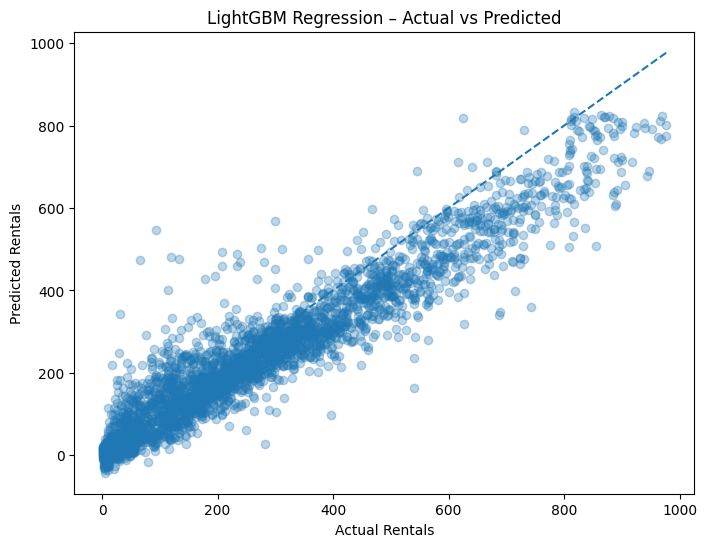

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(test_target, prediction, alpha=0.3)
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         linestyle="--")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("LightGBM Regression – Actual vs Predicted")
plt.show()

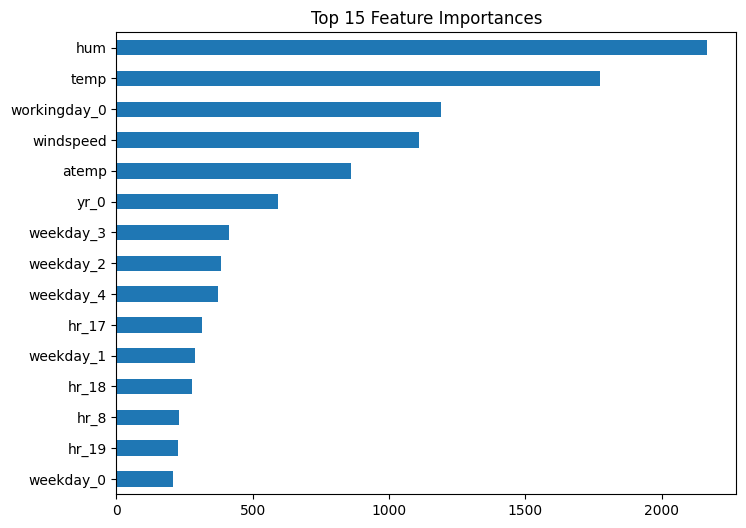

In [34]:
importances = pd.Series(
    model.feature_importances_,
    index=train_features.columns
).sort_values(ascending=False)

importances.head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()
